In [1]:
import torch, os
from PIL import Image
import torch, torch.nn.functional as F
import pytorch_lightning as pl
import torchvision.transforms as transforms
# from pytorch_lightning import Trainer, LightningDataModule

from src.mae import MAEPretrainer, get_mae_model
from src.datasets import EchoDataModule, EchoPretrainDataset

/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import yaml

with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)


## FINE TUNE

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),          # yields (1,H,W)
    transforms.Normalize(0.5, 0.5)
])

In [ ]:
path =  cfg['dataset']['image_path'] # testing
names = os.listdir(path)
records = [os.path.join(path, name) for name in names]
print(len(records))

test_path = '/home/suetin/Projects/UltrasoundCardiacReconstruction/HeartReconstruction/data/train/echoLV/testing/images' 
test_names = os.listdir(test_path)
test_records = [os.path.join(test_path, name) for name in test_names]

records = records + test_records

print(f"Total records: {len(records)}")


# assume `records` is loaded list of JSON dicts
dm = EchoDataModule(records, batch_size=32, transform=transform)
model = MAEPretrainer(cfg)

trainer = pl.Trainer(
    max_epochs=cfg['epochs'],
    precision=16,        # mixed precision for speed
    accelerator="auto",
    gradient_clip_val=1.0,
    accumulate_grad_batches=5,
)
trainer.fit(model, dm)

37035
Total records: 42780


/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/lightning_fabric/connector.py:572: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/suetin/Projects/UltrasoundCardiacReconstruction/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a

Epoch 9: 100%|██████████| 1337/1337 [02:58<00:00,  7.49it/s, v_num=3, train_loss=0.0209]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 1337/1337 [03:01<00:00,  7.38it/s, v_num=3, train_loss=0.0209]


In [5]:
model.model.save_pretrained('models/mae_pretrained')

In [6]:

torch.save(model.model.state_dict(), "models/mae_pretrained.pth")

In [7]:
loaded_model = get_mae_model(cfg, "models/mae_pretrained.pth")
# loaded_model

## EVALUATE

In [8]:
import matplotlib.pyplot as plt

In [9]:
def min_max_scale(x):
    return (x - x.min()) / (x.max() - x.min())

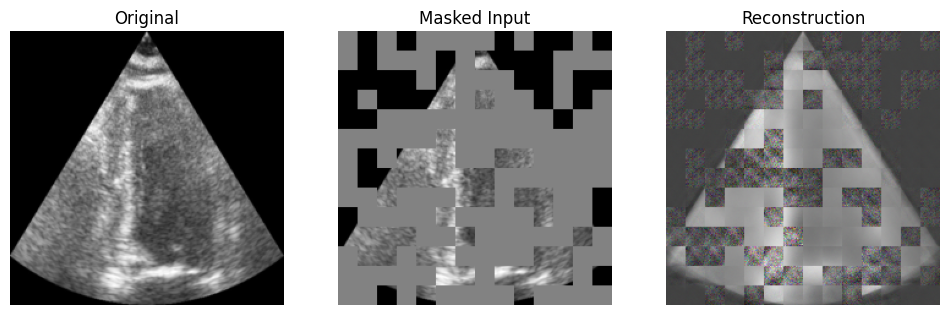

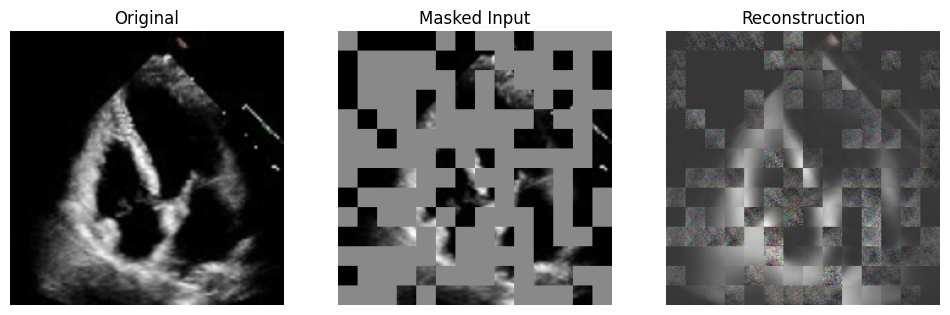

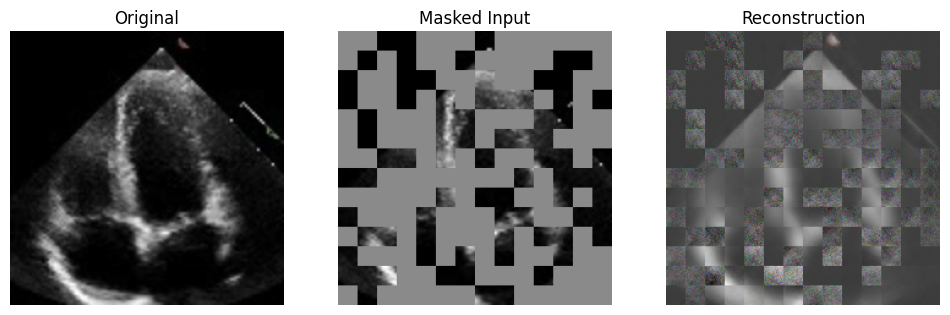

In [10]:
test_paths = records[:3]
ds = EchoPretrainDataset(test_paths, transform)  #   EchoEvalDataset
dl = torch.utils.data.DataLoader(ds, batch_size=3)  # 

# 1. Run one batch
with torch.no_grad():
    model.eval()
    batch = next(iter(dl))  # dict or tensor: shape (B,1,224,224)
    outputs = model(batch)  # ViTMAEForPreTraining or your MAE model
    logits = outputs.logits        # (B, N, patch_dim)
    mask = outputs.mask.to(torch.bool)       # (B, N)  True = masked
    originals = batch['pixel_values']                # (B,1,H,W)

# 2. Unpatchify to images
#    Assuming your MAE model has patchify/unpatchify methods
reconstructed = model.model.unpatchify(logits.cpu())      # (B,1,H,W)
patched = model.model.patchify(originals.cpu())           # (B,N,patch_dim)
# Zero out masked patches
patched[mask] = 0
masked_inputs = model.model.unpatchify(patched)           # (B,1,H,W)

# 3. Convert to CPU numpy arrays & transpose to HxWxC
def to_numpy(img_tensor):
    # img_tensor: (1,H,W) or (H,W)
    arr = img_tensor.squeeze().cpu().numpy()  # (H,W)
    if cfg['num_channels'] == 3:
        arr = arr.transpose(1, 2, 0)
    return arr

# 4. Plot side by side
B = originals.shape[0]
for i in range(min(B, 3)):
    inp = min_max_scale(to_numpy(originals[i]))
    msk = min_max_scale(to_numpy(masked_inputs[i]))
    rec = min_max_scale(to_numpy(reconstructed[i]))

    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    axes[0].imshow(inp, cmap='gray'); axes[0].set_title("Original")
    axes[1].imshow(msk, cmap='gray'); axes[1].set_title("Masked Input")
    axes[2].imshow(rec, cmap='gray'); axes[2].set_title("Reconstruction")
    for ax in axes:
        ax.axis('off')
    plt.show()

In [11]:
logits.shape, mask.shape

(torch.Size([3, 196, 768]), torch.Size([3, 196]))

In [12]:
def unpatchify(logits, patch_size=16, channels=3):
    """
    logits: tensor of shape (B, 196, 768)
    returns: tensor of shape (B, 3, 224, 224)
    """
    B, N, D = logits.shape
    h = w = int(N ** 0.5)  # e.g., 14
    assert D == patch_size * patch_size * channels, "Mismatch in patch_dim"

    patches = logits.reshape(B, h, w, patch_size, patch_size, channels)  # (B, 14, 14, 16, 16, 3)
    patches = patches.permute(0, 5, 1, 3, 2, 4)  # (B, 3, 14, 16, 14, 16)
    images = patches.reshape(B, channels, h * patch_size, w * patch_size)  # (B, 3, 224, 224)
    return images

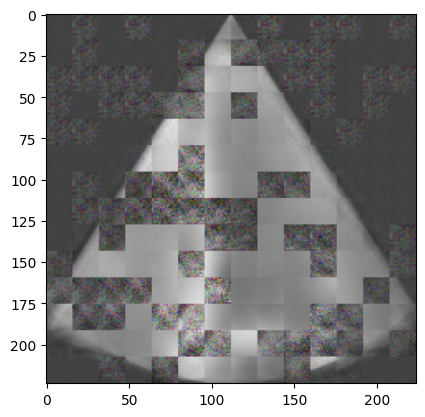

In [13]:
images = unpatchify(logits, patch_size=16, channels=3)  # (3, 3, 224, 224)

# For visualization
img_np = images[0].permute(1, 2, 0).cpu().numpy()  # → (224, 224, 3)
plt.imshow(min_max_scale(to_numpy(images[0])))
plt.show()

In [23]:
def unpatchify_with_original_visible(logits, pixel_values, mask, patch_size=16, channels=3):
    """
    logits: MAE output → shape (B, N, patch_dim)
    pixel_values: original images → (B, 3, 224, 224)
    mask: boolean mask → (B, N), True = masked
    Returns: reconstructed image (B, 3, 224, 224)
    """
    B, N, D = logits.shape
    assert D == patch_size * patch_size * channels, "Patch dim mismatch"

    # Step 1: patchify original images
    def patchify(imgs):
        B, C, H, W = imgs.shape
        h = w = H // patch_size
        patches = imgs.reshape(B, C, h, patch_size, w, patch_size)
        patches = patches.permute(0, 2, 4, 3, 5, 1)  # (B, h, w, p, p, C)
        patches = patches.reshape(B, h * w, patch_size * patch_size * C)
        return patches

    original_patches = patchify(pixel_values)

    # Step 2: replace unmasked patches in logits with original
    final_patches = logits.clone()
    final_patches[~mask] = original_patches[~mask]  # only unmasked get replaced

    # Step 3: unpatchify
    h = w = int(N ** 0.5)
    patches = final_patches.reshape(B, h, w, patch_size, patch_size, channels)
    patches = patches.permute(0, 5, 1, 3, 2, 4)  # (B, C, h, p, w, p)
    imgs = patches.reshape(B, channels, h * patch_size, w * patch_size)
    return imgs

In [24]:
reconstructed = unpatchify_with_original_visible(
    logits=outputs.logits,
    pixel_values=batch["pixel_values"],
    mask=outputs.mask.to(torch.bool),
    patch_size=16,
    channels=3
)

In [16]:
reconstructed.shape

torch.Size([3, 3, 224, 224])

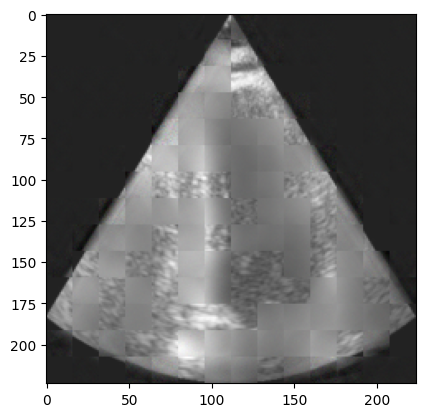

In [25]:
plt.imshow(min_max_scale(to_numpy(reconstructed[0])))

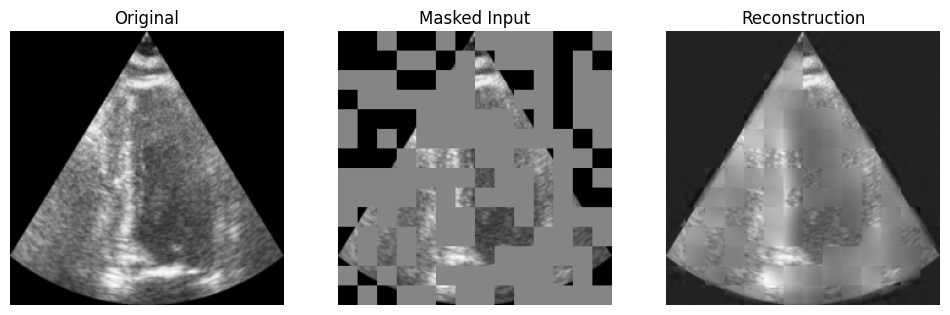

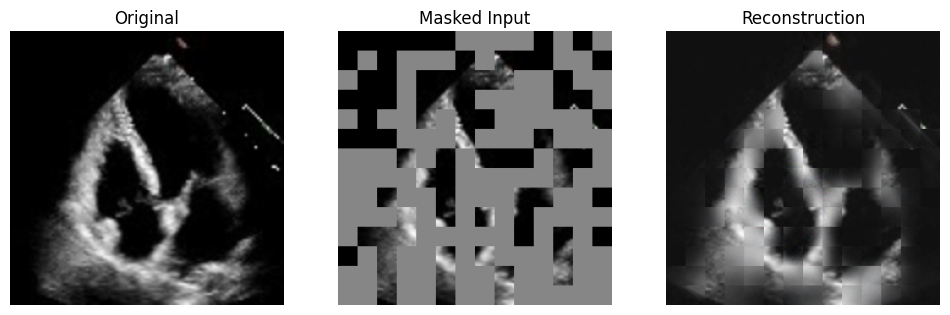

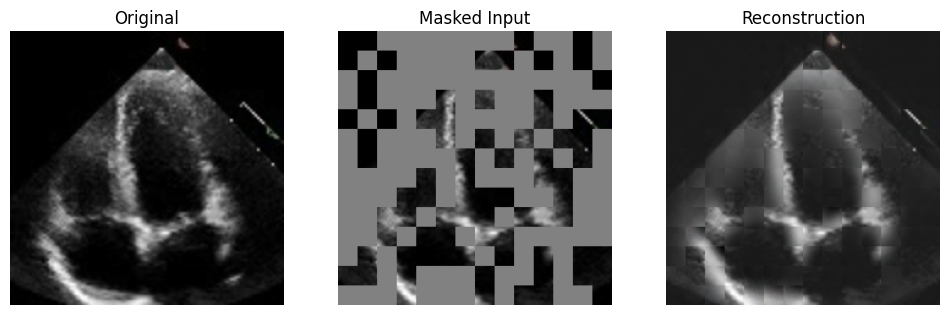

In [26]:
B = originals.shape[0]
for i in range(min(B, 3)):
    inp = min_max_scale(to_numpy(originals[i]))
    msk = min_max_scale(to_numpy(masked_inputs[i]))
    rec = min_max_scale(to_numpy(reconstructed[i]))

    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    axes[0].imshow(inp, cmap='gray'); axes[0].set_title("Original")
    axes[1].imshow(msk, cmap='gray'); axes[1].set_title("Masked Input")
    axes[2].imshow(rec, cmap='gray'); axes[2].set_title("Reconstruction")
    for ax in axes:
        ax.axis('off')
    plt.show()

In [19]:
loaded_model(batch['pixel_values']).keys()  # (B, 3, 224, 224)

odict_keys(['loss', 'logits', 'mask', 'ids_restore'])

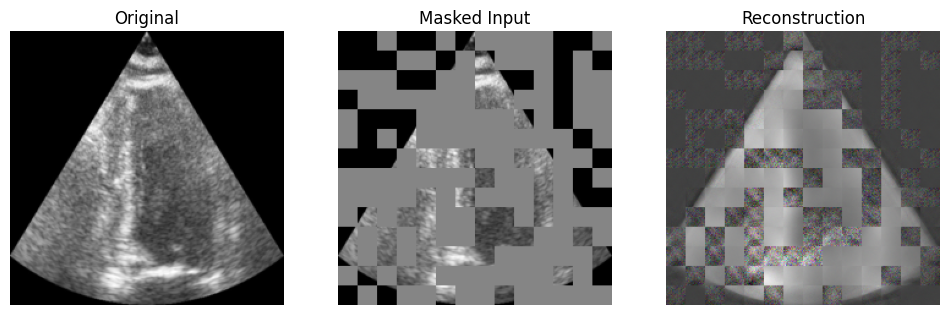

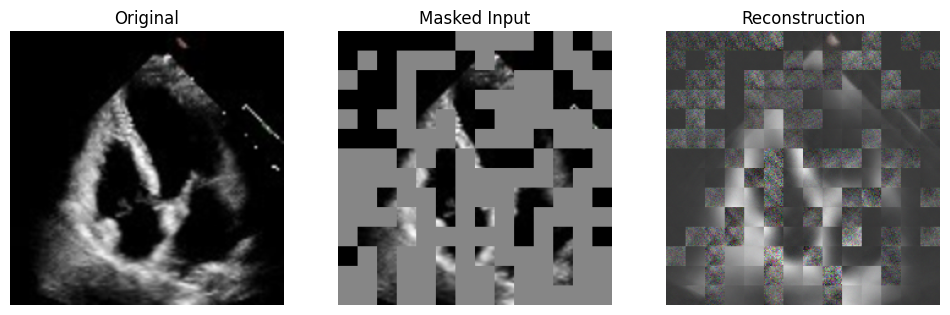

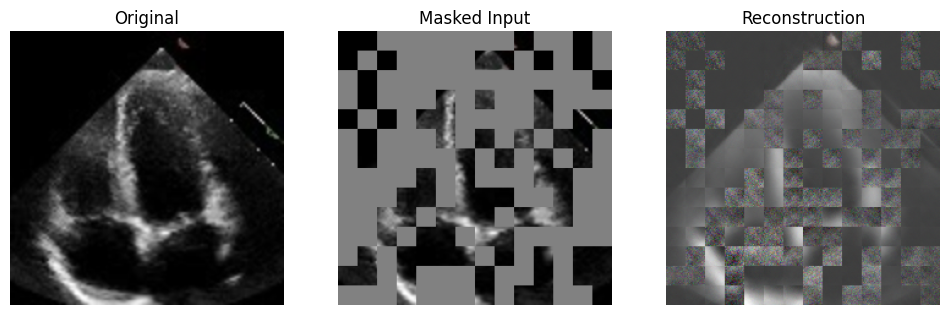

In [20]:
test_paths = records[:3]
ds = EchoPretrainDataset(test_paths, transform)  #   EchoEvalDataset
dl = torch.utils.data.DataLoader(ds, batch_size=3)  # 

# 1. Run one batch
with torch.no_grad():
    loaded_model.eval()
    batch = next(iter(dl))  # dict or tensor: shape (B,1,224,224)
    outputs = loaded_model(batch['pixel_values'])  # ViTMAEForPreTraining or your MAE model
    logits = outputs.logits        # (B, N, patch_dim)
    mask = outputs.mask.to(torch.bool)       # (B, N)  True = masked
    originals = batch['pixel_values']                # (B,1,H,W)

# 2. Unpatchify to images
#    Assuming your MAE model has patchify/unpatchify methods
reconstructed = loaded_model.unpatchify(logits.cpu())      # (B,1,H,W)
patched = loaded_model.patchify(originals.cpu())           # (B,N,patch_dim)
# Zero out masked patches
patched[mask] = 0
masked_inputs = loaded_model.unpatchify(patched)           # (B,1,H,W)

# 3. Convert to CPU numpy arrays & transpose to HxWxC
def to_numpy(img_tensor):
    # img_tensor: (1,H,W) or (H,W)
    arr = img_tensor.squeeze().cpu().numpy()  # (H,W)
    if cfg['num_channels'] == 3:
        arr = arr.transpose(1, 2, 0)
    return arr

# 4. Plot side by side
B = originals.shape[0]
for i in range(min(B, 3)):
    inp = min_max_scale(to_numpy(originals[i]))
    msk = min_max_scale(to_numpy(masked_inputs[i]))
    rec = min_max_scale(to_numpy(reconstructed[i]))

    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    axes[0].imshow(inp, cmap='gray'); axes[0].set_title("Original")
    axes[1].imshow(msk, cmap='gray'); axes[1].set_title("Masked Input")
    axes[2].imshow(rec, cmap='gray'); axes[2].set_title("Reconstruction")
    for ax in axes:
        ax.axis('off')
    plt.show()

In [21]:
loaded_model.state_dict().keys()  # (B, 3, 224, 224)

odict_keys(['vit.embeddings.cls_token', 'vit.embeddings.position_embeddings', 'vit.embeddings.patch_embeddings.projection.weight', 'vit.embeddings.patch_embeddings.projection.bias', 'vit.encoder.layer.0.attention.attention.query.weight', 'vit.encoder.layer.0.attention.attention.query.bias', 'vit.encoder.layer.0.attention.attention.key.weight', 'vit.encoder.layer.0.attention.attention.key.bias', 'vit.encoder.layer.0.attention.attention.value.weight', 'vit.encoder.layer.0.attention.attention.value.bias', 'vit.encoder.layer.0.attention.output.dense.weight', 'vit.encoder.layer.0.attention.output.dense.bias', 'vit.encoder.layer.0.intermediate.dense.weight', 'vit.encoder.layer.0.intermediate.dense.bias', 'vit.encoder.layer.0.output.dense.weight', 'vit.encoder.layer.0.output.dense.bias', 'vit.encoder.layer.0.layernorm_before.weight', 'vit.encoder.layer.0.layernorm_before.bias', 'vit.encoder.layer.0.layernorm_after.weight', 'vit.encoder.layer.0.layernorm_after.bias', 'vit.encoder.layer.1.atten